In [2]:
import  pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [3]:
sales_data = pd.read_csv("../data/raw/sales_data_sample.csv")

In [4]:
sales_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   object 
 6   STATUS            2823 non-null   object 
 7   QTR_ID            2823 non-null   int64  
 8   MONTH_ID          2823 non-null   int64  
 9   YEAR_ID           2823 non-null   int64  
 10  PRODUCTLINE       2823 non-null   object 
 11  MSRP              2823 non-null   int64  
 12  PRODUCTCODE       2823 non-null   object 
 13  CUSTOMERNAME      2823 non-null   object 
 14  PHONE             2823 non-null   object 
 15  ADDRESSLINE1      2823 non-null   object 
 16  ADDRESSLINE2      302 non-null    object 


In [5]:
sales_data.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


In [6]:
sales_data["ORDERDATE"] = pd.to_datetime(sales_data["ORDERDATE"])

In [7]:
sales_data.duplicated().sum()

np.int64(0)

In [8]:
sales_data.isnull().sum()

ORDERNUMBER            0
QUANTITYORDERED        0
PRICEEACH              0
ORDERLINENUMBER        0
SALES                  0
ORDERDATE              0
STATUS                 0
QTR_ID                 0
MONTH_ID               0
YEAR_ID                0
PRODUCTLINE            0
MSRP                   0
PRODUCTCODE            0
CUSTOMERNAME           0
PHONE                  0
ADDRESSLINE1           0
ADDRESSLINE2        2521
CITY                   0
STATE               1486
POSTALCODE            76
COUNTRY                0
TERRITORY           1074
CONTACTLASTNAME        0
CONTACTFIRSTNAME       0
DEALSIZE               0
dtype: int64

In [9]:
sales_data["ADDRESSLINE2"] = sales_data["ADDRESSLINE2"].fillna("Missing")
sales_data["STATE"] = sales_data["STATE"].fillna("Missing")
sales_data["POSTALCODE"] = sales_data["POSTALCODE"].fillna("Missing")
sales_data["TERRITORY"] = sales_data["TERRITORY"].fillna("Missing")

In [10]:
sales_data.isnull().sum()


ORDERNUMBER         0
QUANTITYORDERED     0
PRICEEACH           0
ORDERLINENUMBER     0
SALES               0
ORDERDATE           0
STATUS              0
QTR_ID              0
MONTH_ID            0
YEAR_ID             0
PRODUCTLINE         0
MSRP                0
PRODUCTCODE         0
CUSTOMERNAME        0
PHONE               0
ADDRESSLINE1        0
ADDRESSLINE2        0
CITY                0
STATE               0
POSTALCODE          0
COUNTRY             0
TERRITORY           0
CONTACTLASTNAME     0
CONTACTFIRSTNAME    0
DEALSIZE            0
dtype: int64

In [11]:
sales_data = sales_data[sales_data["STATUS"] == "Shipped"]

In [12]:
sales_data.info()


<class 'pandas.core.frame.DataFrame'>
Index: 2617 entries, 0 to 2821
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   ORDERNUMBER       2617 non-null   int64         
 1   QUANTITYORDERED   2617 non-null   int64         
 2   PRICEEACH         2617 non-null   float64       
 3   ORDERLINENUMBER   2617 non-null   int64         
 4   SALES             2617 non-null   float64       
 5   ORDERDATE         2617 non-null   datetime64[ns]
 6   STATUS            2617 non-null   object        
 7   QTR_ID            2617 non-null   int64         
 8   MONTH_ID          2617 non-null   int64         
 9   YEAR_ID           2617 non-null   int64         
 10  PRODUCTLINE       2617 non-null   object        
 11  MSRP              2617 non-null   int64         
 12  PRODUCTCODE       2617 non-null   object        
 13  CUSTOMERNAME      2617 non-null   object        
 14  PHONE             2617 non-nu

YEAR_ID
2003    3439718.03
2004    4528047.22
2005    1323735.83
Name: SALES, dtype: float64


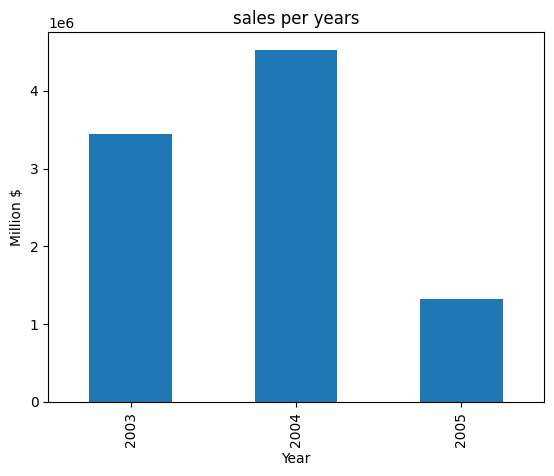

In [13]:
print(sales_data.groupby("YEAR_ID")["SALES"].sum())
sales_data.groupby("YEAR_ID")["SALES"].sum().plot(kind="bar")
plt.title("sales per years")
plt.ylabel("Million $")
plt.xlabel("Year")
plt.show()

YEAR_ID  QTR_ID
2003     1          445094.69
         2          562365.22
         3          649514.54
         4         1782743.58
2004     1          833730.68
         2          620484.17
         3         1109396.27
         4         1964436.10
2005     1          973903.28
         2          349832.55
Name: SALES, dtype: float64


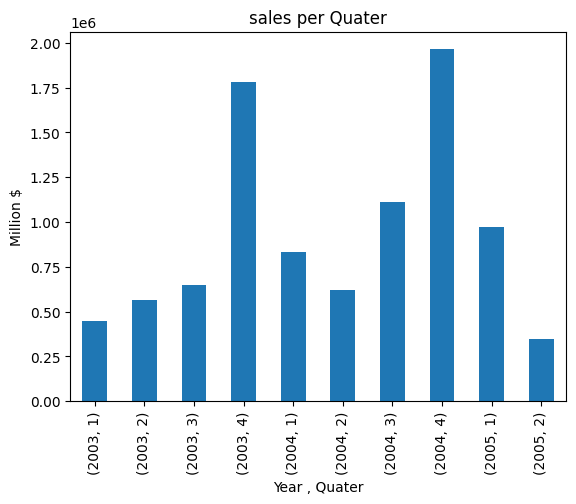

In [14]:
print(sales_data.groupby(["YEAR_ID", "QTR_ID"])["SALES"].sum())
sales_data.groupby(["YEAR_ID", "QTR_ID"])["SALES"].sum().plot(kind="bar")
plt.title("sales per Quater")
plt.ylabel("Million $")
plt.xlabel("Year , Quater")
plt.show()

PRODUCTLINE
Classic Cars        3701760.33
Motorcycles         1129573.83
Planes               866466.57
Ships                591172.76
Trains               215352.57
Trucks and Buses    1044097.39
Vintage Cars        1743077.63
Name: SALES, dtype: float64


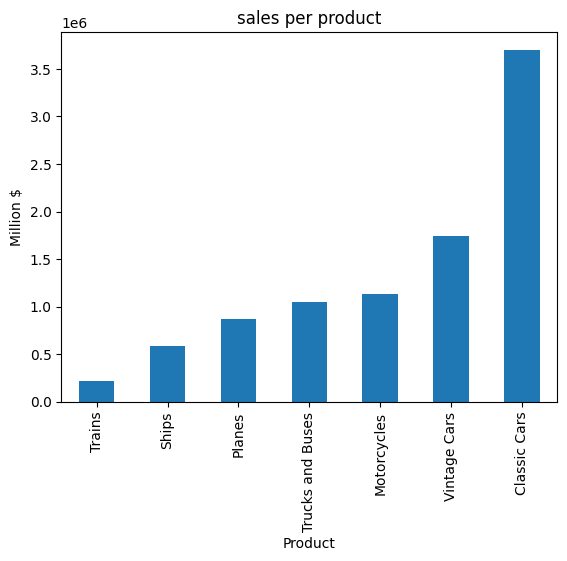

In [15]:
print(sales_data.groupby("PRODUCTLINE")["SALES"].sum())
sales_data.groupby("PRODUCTLINE")["SALES"].sum().sort_values().plot(kind="bar")
plt.title("sales per product")
plt.ylabel("Million $")
plt.xlabel("Product")
plt.show()

COUNTRY
Australia       572273.58
Austria         173511.94
Belgium         100000.67
Canada          224078.56
Denmark         195545.67
Finland         329581.91
France         1067131.83
Germany         220472.09
Ireland          57756.43
Italy           374674.31
Japan           188167.81
Norway          307463.70
Philippines      94015.73
Singapore       288488.41
Spain          1044905.31
Sweden          135043.08
Switzerland     117713.56
UK              428472.21
USA            3372204.28
Name: SALES, dtype: float64


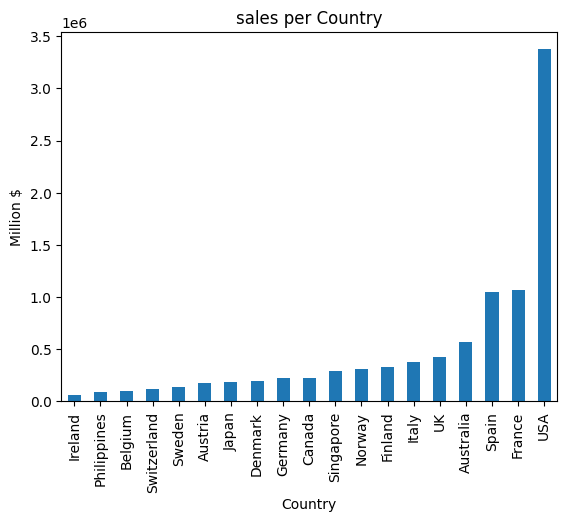

In [16]:
print(sales_data.groupby("COUNTRY")["SALES"].sum())
sales_data.groupby("COUNTRY")["SALES"].sum().sort_values().plot(kind="bar")
plt.title("sales per Country")
plt.ylabel("Million $")
plt.xlabel("Country")
plt.show()

YEAR_ID  MONTH_ID
2003     1            129753.60
         2            140836.19
         3            174504.90
         4            201609.55
         5            192673.11
         6            168082.56
         7            187731.88
         8            197809.30
         9            263973.36
         10           491029.46
         11          1029837.66
         12           261876.46
2004     1            316577.42
         2            311419.53
         3            205733.73
         4            206148.12
         5            228080.73
         6            186255.32
         7            327144.09
         8            461501.27
         9            320750.91
         10           552924.25
         11          1038709.19
         12           372802.66
2005     1            295270.06
         2            358186.18
         3            320447.04
         4            131218.33
         5            218614.22
Name: SALES, dtype: float64


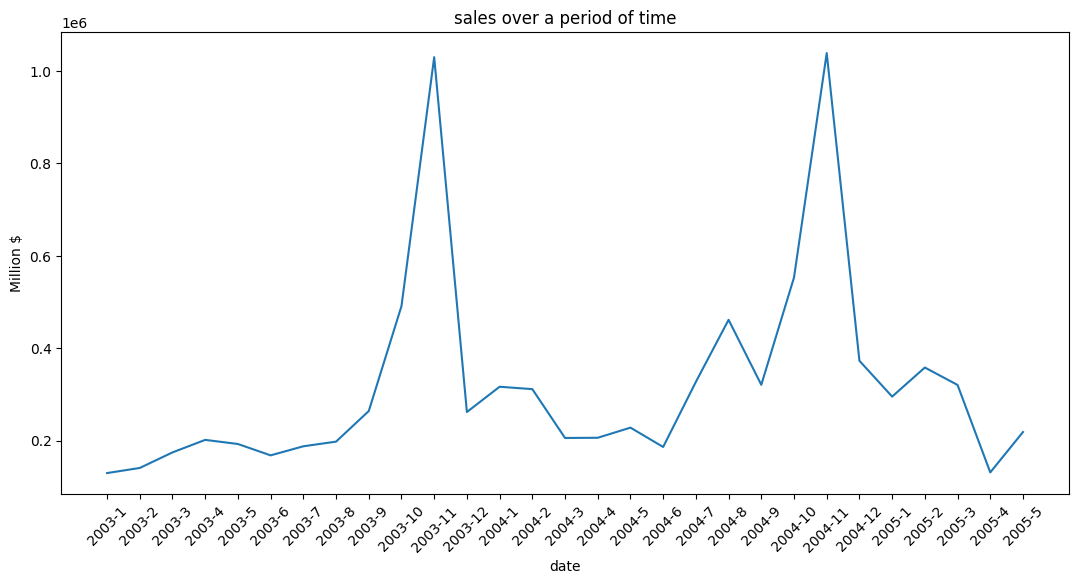

In [17]:
print(sales_data.groupby(["YEAR_ID", "MONTH_ID"])["SALES"].sum())
grouped = sales_data.groupby(["YEAR_ID", "MONTH_ID"])["SALES"].sum()
x = [f"{y}-{m}" for y, m in grouped.index]
grouped.plot(kind="line",  figsize=[13, 6])
plt.xticks(range(len(x)), x, rotation= 45)
plt.title("sales over a period of time")
plt.ylabel("Million $")
plt.xlabel("date")
plt.show()

PRODUCTLINE
Classic Cars        3701760.33
Motorcycles         1129573.83
Planes               866466.57
Ships                591172.76
Trains               215352.57
Trucks and Buses    1044097.39
Vintage Cars        1743077.63
Name: SALES, dtype: float64


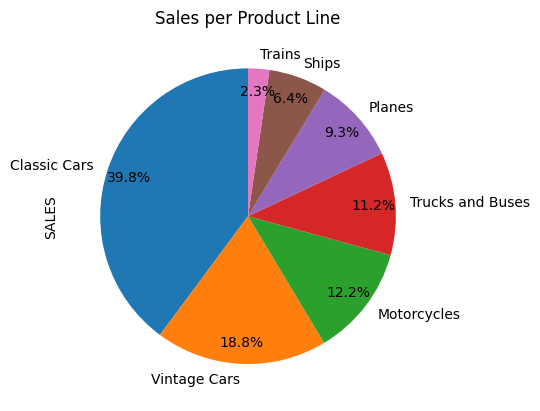

In [18]:
print(sales_data.groupby("PRODUCTLINE")["SALES"].sum())
sales_data.groupby("PRODUCTLINE")["SALES"].sum().sort_values(ascending=False).plot(
    kind="pie", 
    autopct='%1.1f%%', 
    startangle=90, 
    pctdistance=0.85 , 
)
plt.title("Sales per Product Line")
plt.show()

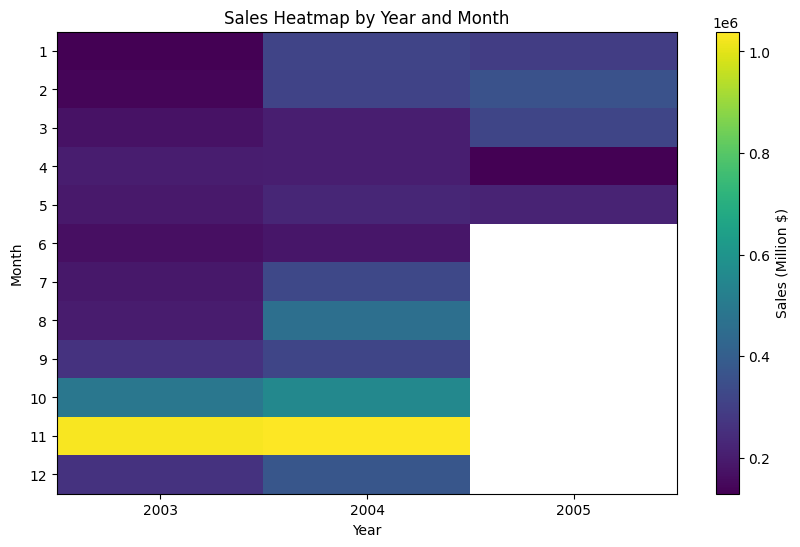

In [19]:
# Create heatmap for sales by year and month
grouped = sales_data.groupby(["YEAR_ID", "MONTH_ID"])["SALES"].sum().reset_index()
pivot = grouped.pivot(index="MONTH_ID", columns="YEAR_ID", values="SALES")

plt.figure(figsize=(10, 6))
plt.imshow(pivot, cmap='viridis', aspect='auto')
plt.colorbar(label='Sales (Million $)')
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.xlabel('Year')
plt.ylabel('Month')
plt.title('Sales Heatmap by Year and Month')
plt.show()